# 1. Exploring the data

**Question:** do criminal offence rates and gambling losses predict median house
prices across Victoria's Local Government Areas (LGAs)?

This notebook establishes what the data looks like before any model is fitted:
the distribution of each variable, the price bands used as the classification
target, and the structure of the panel. The last of those turns out to matter
more than anything else in the project, so it gets its own section at the end.

Every figure here is written to `figures/` by `vichouse.plotting.save_fig`, and
every table to `results/`. The pipeline that produces the input is
`python -m vichouse.pipeline`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from vichouse import config, plotting
from vichouse.build_dataset import FEATURES, TARGET
from vichouse.config import PRICE_HIGH, PRICE_LOW, RESULTS, SEED

plotting.apply_style()
config.RESULTS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(config.MODELLING_DATASET_CSV)
df[TARGET] = pd.Categorical(df[TARGET], categories=config.PRICE_LABELS, ordered=True)

print(f"{len(df)} rows: {df['LGA'].nunique()} LGAs x {df['Year'].nunique()} years")
print(f"years: {df['Year'].min()}-{df['Year'].max()}")
df.head()

170 rows: 34 LGAs x 5 years
years: 2016-2020


,LGA,Year,Weighted House Price,Type A Percentage,Type B Percentage,Type C Percentage,Type D Percentage,Type E Percentage,Offence Rate,Total Loss On EGM,EGM Rate,Price Level,EGM Split
0,Ballarat,2016,334852.68,15.16,61.04,4.03,5.67,13.86,11679.23,54611247.32,466.93,Low,False
1,Ballarat,2017,360223.85,16.14,60.04,3.26,5.56,14.83,10973.84,54568804.35,466.57,Low,False
2,Ballarat,2018,396334.04,16.96,55.31,3.99,6.33,17.23,10097.76,55763965.38,476.79,Low,False
3,Ballarat,2019,426034.96,13.58,62.96,3.51,4.69,15.13,10695.71,57540687.41,491.98,Low,False
4,Ballarat,2020,486200.09,16.22,51.98,4.29,5.18,18.72,8746.47,43713216.26,373.75,Low,False


## 1.1 The three variables

* **Weighted House Price** -- each LGA's median house price, built by weighting
  its suburbs' medians by population share. Suburbs with no recorded price in a
  given year are excluded from both the numerator and the denominator.
* **Offence Rate** -- offences per 100,000 residents, summed across the Crime
  Statistics Agency's offence subdivisions.
* **EGM Rate** -- electronic gaming machine losses in dollars per resident per
  year.

In [2]:
summary = df[["Weighted House Price", "Offence Rate", "EGM Rate"]].describe().T
summary["skew"] = df[["Weighted House Price", "Offence Rate", "EGM Rate"]].skew()
summary.round(2)

,count,mean,std,min,25%,50%,75%,max,skew
Weighted House Price,170.0,987509.22,492889.72,334852.68,632378.66,872387.36,1193973.07,2546046.84,1.21
Offence Rate,170.0,8164.05,3592.21,3264.54,5974.80,7285.47,9582.60,25932.26,2.15
EGM Rate,170.0,439.33,158.90,75.52,344.91,458.66,537.48,813.86,-0.17


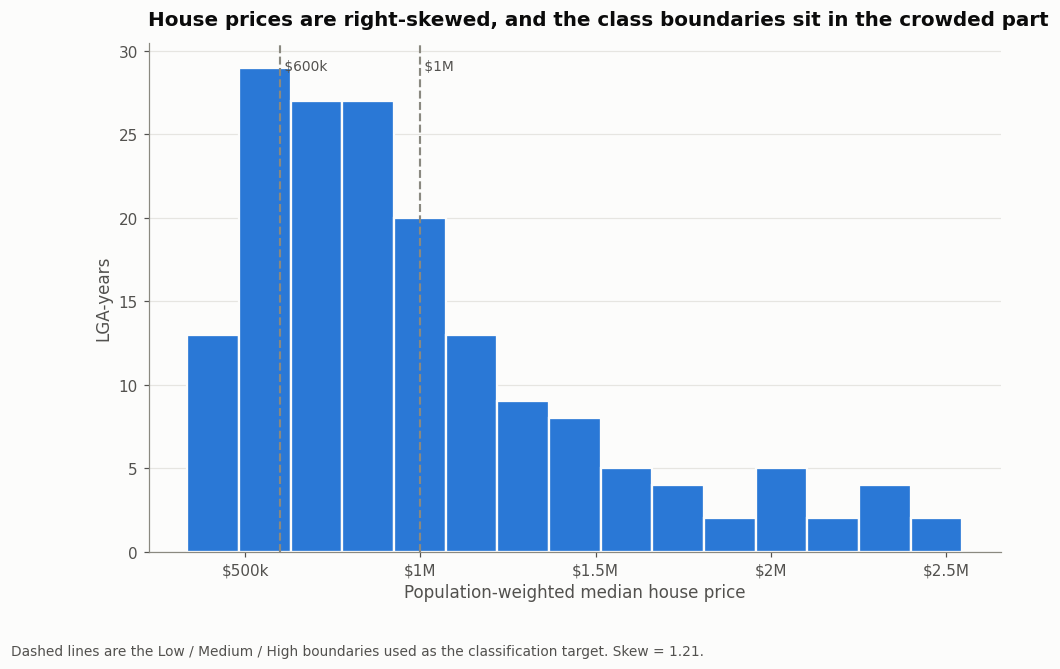

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(
    df["Weighted House Price"],
    bins=15,
    color=plotting.BLUE,
    edgecolor=plotting.SURFACE,
    linewidth=1.5,
)
for boundary, label in [(PRICE_LOW, "$600k"), (PRICE_HIGH, "$1M")]:
    ax.axvline(boundary, color=plotting.REFERENCE, linestyle="--", linewidth=1.4)
    ax.text(
        boundary, ax.get_ylim()[1] * 0.97, " " + label,
        color=plotting.INK_SECONDARY, fontsize=9, va="top",
    )
ax.xaxis.set_major_formatter(plt.FuncFormatter(plotting.thousands))
ax.set_xlabel("Population-weighted median house price")
ax.set_ylabel("LGA-years")
ax.set_title("House prices are right-skewed, and the class boundaries sit in the crowded part")
plotting.caption(
    fig,
    "Dashed lines are the Low / Medium / High boundaries used as the classification target. "
    f"Skew = {df['Weighted House Price'].skew():.2f}.",
)
plotting.save_fig(fig, "01_price_distribution")
plt.show()

The distribution is right-skewed, which has a direct consequence for the
classification task: the $600k boundary falls where the data is densest, so
small differences in price decide the Low/Medium label. The submitted report
identified this as the likely reason the Low class was predicted poorly.

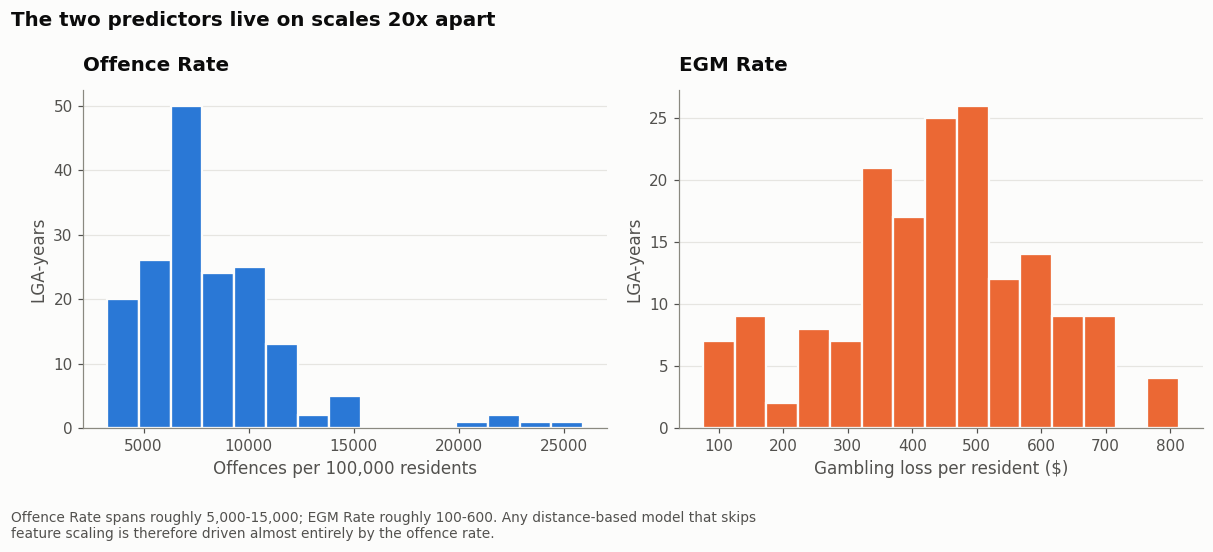

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, column, colour, label in [
    (axes[0], "Offence Rate", plotting.BLUE, "Offences per 100,000 residents"),
    (axes[1], "EGM Rate", plotting.ORANGE, "Gambling loss per resident ($)"),
]:
    ax.hist(df[column], bins=15, color=colour, edgecolor=plotting.SURFACE, linewidth=1.5)
    ax.set_xlabel(label)
    ax.set_ylabel("LGA-years")
    ax.set_title(column)
fig.suptitle(
    "The two predictors live on scales 20x apart", x=0.0, ha="left",
    fontsize=13, fontweight="semibold", color=plotting.INK,
)
plotting.caption(
    fig,
    "Offence Rate spans roughly 5,000-15,000; EGM Rate roughly 100-600. Any distance-based "
    "model that skips feature scaling is therefore driven almost entirely by the offence rate.",
)
fig.tight_layout()
plotting.save_fig(fig, "02_feature_distributions")
plt.show()

That scale gap is not a cosmetic detail. The original project fed these two
columns to a k-nearest-neighbours classifier unscaled, so the Euclidean
distance it relies on was almost entirely the offence rate. Notebook 2
quantifies the effect.

## 1.2 How each predictor relates to price

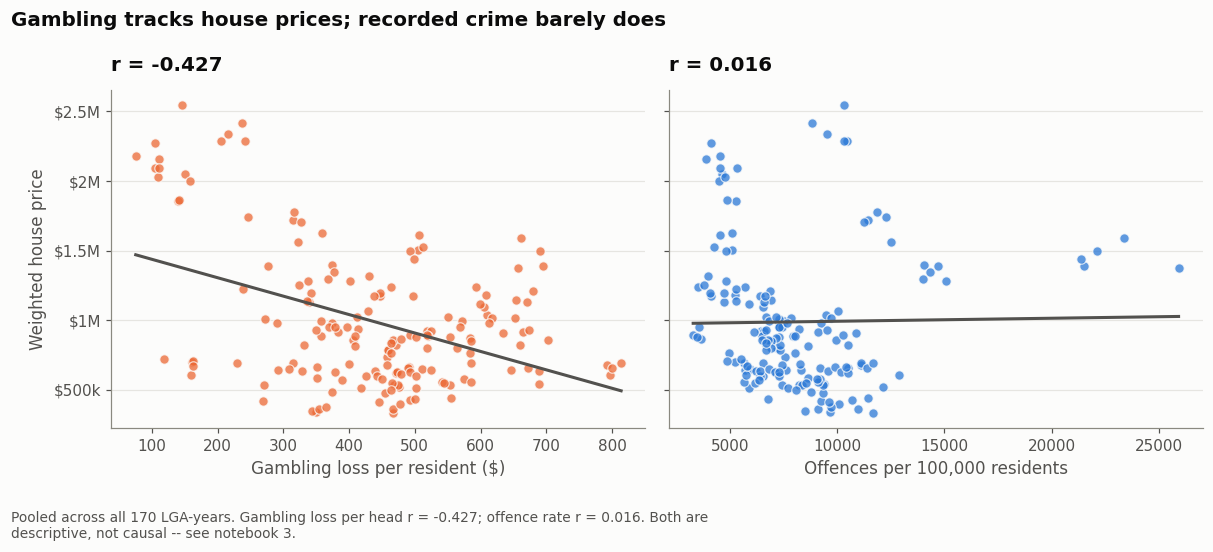

In [5]:
def scatter_with_fit(ax, x, y, colour, xlabel):
    ax.scatter(x, y, s=38, color=colour, alpha=0.75, edgecolor=plotting.SURFACE, linewidth=0.8)
    slope, intercept = np.polyfit(x, y, 1)
    grid = np.linspace(x.min(), x.max(), 100)
    ax.plot(grid, slope * grid + intercept, color=plotting.INK_SECONDARY, linewidth=2)
    r = np.corrcoef(x, y)[0, 1]
    ax.set_xlabel(xlabel)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(plotting.thousands))
    ax.set_title(f"r = {r:.3f}")
    return r


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
r_egm = scatter_with_fit(
    axes[0], df["EGM Rate"], df["Weighted House Price"], plotting.ORANGE,
    "Gambling loss per resident ($)",
)
r_off = scatter_with_fit(
    axes[1], df["Offence Rate"], df["Weighted House Price"], plotting.BLUE,
    "Offences per 100,000 residents",
)
axes[0].set_ylabel("Weighted house price")
fig.suptitle(
    "Gambling tracks house prices; recorded crime barely does", x=0.0, ha="left",
    fontsize=13, fontweight="semibold", color=plotting.INK,
)
plotting.caption(
    fig,
    f"Pooled across all 170 LGA-years. Gambling loss per head r = {r_egm:.3f}; "
    f"offence rate r = {r_off:.3f}. Both are descriptive, not causal -- see notebook 3.",
)
fig.tight_layout()
plotting.save_fig(fig, "03_price_vs_predictors")
plt.show()

Gambling loss per head is negatively associated with house prices: more is lost
per resident in cheaper areas. The recorded offence rate shows almost nothing
pooled across all years.

Note this is an **ecological** relationship, measured across 34 aggregate areas.
It says nothing about individual households or individual gamblers.

## 1.3 The class balance

The target is the price band. The boundaries are the submitted report's, chosen
on domain grounds rather than from quantiles.

In [6]:
balance = df[TARGET].value_counts().reindex(config.PRICE_LABELS)
majority = balance.max() / len(df)
print(balance.to_string())
print(f"\nmajority-class share: {balance.max()}/{len(df)} = {majority:.4f}")
print("Any classifier must beat this to be doing anything at all.")

Price Level
Low       32
Medium    77
High      61

majority-class share: 77/170 = 0.4529
Any classifier must beat this to be doing anything at all.


## 1.4 The panel structure, and why it decides everything

The dataset is a **panel**: 34 LGAs observed over 5 years. That is 170 rows but
only 34 independent units, and the five rows belonging to one council are nearly
identical -- a council's crime rate and gambling spend barely move year to year,
and its price band usually does not move at all.

This matters because of how the original project split the data. It sampled
*rows* at random, so roughly four of each council's five rows landed in the
training set and the fifth in the test set. A model can then score well by
recognising which council a row belongs to, without having learned anything
about the relationship under study.

The two measurements below are what the rest of the project rests on.

In [7]:
# How much of each predictor's variation is between councils rather than within
# one council over time? If almost all of it is between councils, then knowing
# the council is almost as good as knowing the features.
variance = {}
for column in FEATURES:
    within = df.groupby("LGA")[column].transform("mean")
    between_var = within.var(ddof=0)
    total_var = df[column].var(ddof=0)
    variance[column] = between_var / total_var

for column, share in variance.items():
    print(f"{column:14s}: {share:.1%} of variance is between councils, not within")

constant = df.groupby("LGA")[TARGET].nunique().eq(1).sum()
print(
    f"\nCouncils whose price band never changes across all 5 years: "
    f"{constant}/{df['LGA'].nunique()}"
)

Offence Rate  : 97.4% of variance is between councils, not within
EGM Rate      : 89.3% of variance is between councils, not within

Councils whose price band never changes across all 5 years: 25/34


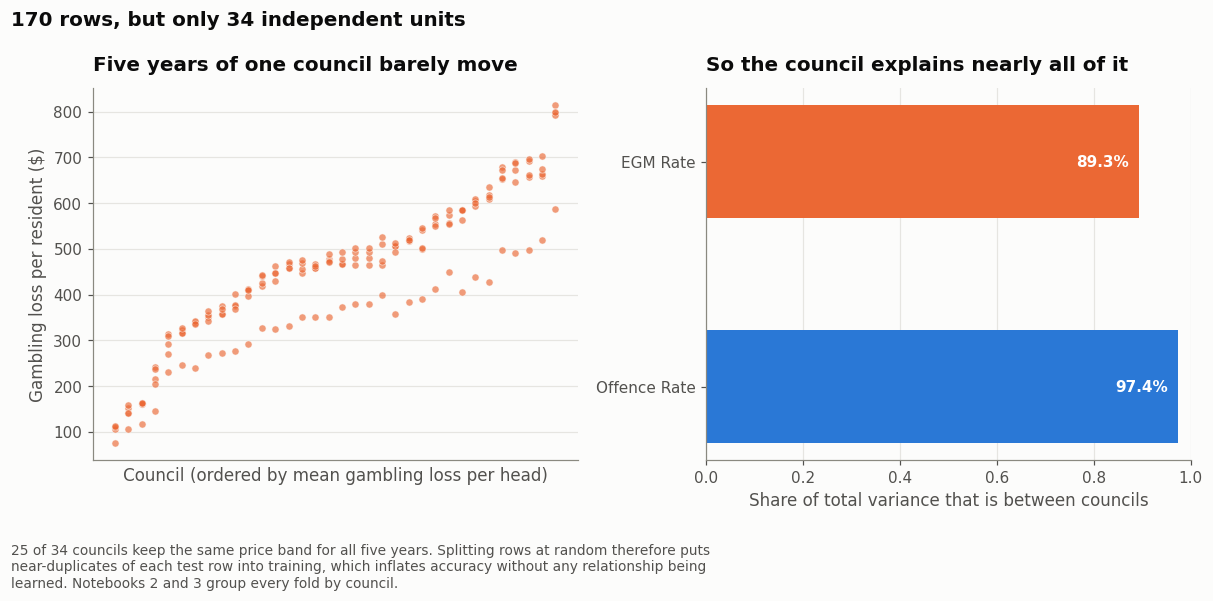

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

# Left: each council's five yearly values, to show how tight they are.
order = df.groupby("LGA")["EGM Rate"].mean().sort_values().index
positions = {lga: i for i, lga in enumerate(order)}
axes[0].scatter(
    df["LGA"].map(positions), df["EGM Rate"],
    s=22, color=plotting.ORANGE, alpha=0.65,
    edgecolor=plotting.SURFACE, linewidth=0.5,
)
axes[0].set_xlabel("Council (ordered by mean gambling loss per head)")
axes[0].set_ylabel("Gambling loss per resident ($)")
axes[0].set_title("Five years of one council barely move")
axes[0].set_xticks([])

# Right: share of variance that is between councils.
labels = list(variance)
values = [variance[c] for c in labels]
bars = axes[1].barh(labels, values, color=[plotting.BLUE, plotting.ORANGE], height=0.5)
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("Share of total variance that is between councils")
axes[1].set_title("So the council explains nearly all of it")
axes[1].grid(axis="x")
axes[1].grid(axis="y", visible=False)
for bar, value in zip(bars, values):
    axes[1].text(
        value - 0.02, bar.get_y() + bar.get_height() / 2, f"{value:.1%}",
        va="center", ha="right", color="white", fontsize=10, fontweight="semibold",
    )

fig.suptitle(
    "170 rows, but only 34 independent units", x=0.0, ha="left",
    fontsize=13, fontweight="semibold", color=plotting.INK,
)
plotting.caption(
    fig,
    f"{constant} of 34 councils keep the same price band for all five years. Splitting rows at "
    "random therefore puts near-duplicates of each test row into training, which inflates "
    "accuracy without any relationship being learned. Notebooks 2 and 3 group every fold by council.",
)
fig.tight_layout()
plotting.save_fig(fig, "04_panel_structure")
plt.show()

This is the single most consequential thing in the dataset, and the original
project did not account for it. Both model notebooks therefore report two
numbers side by side: the original row-wise protocol, for comparability with the
submitted report, and cross-validation with folds **grouped by council**, which
is the figure to believe.

## 1.5 The population denominator

Every per-capita figure here -- the price weighting, the offence rate, the
gambling rate -- needs a population per area. The source community profile
provides estimated resident population for **2007 and 2012 only**, so the
original project used the 2012 estimate for all years from 2016 to 2020, on the
grounds that a systematic error is more defensible than an imputed one.

The figure below shows what the alternatives would have looked like, and is the
reason the simple choice was kept: extrapolating from two points eight years out
is not obviously better than holding the last known value.

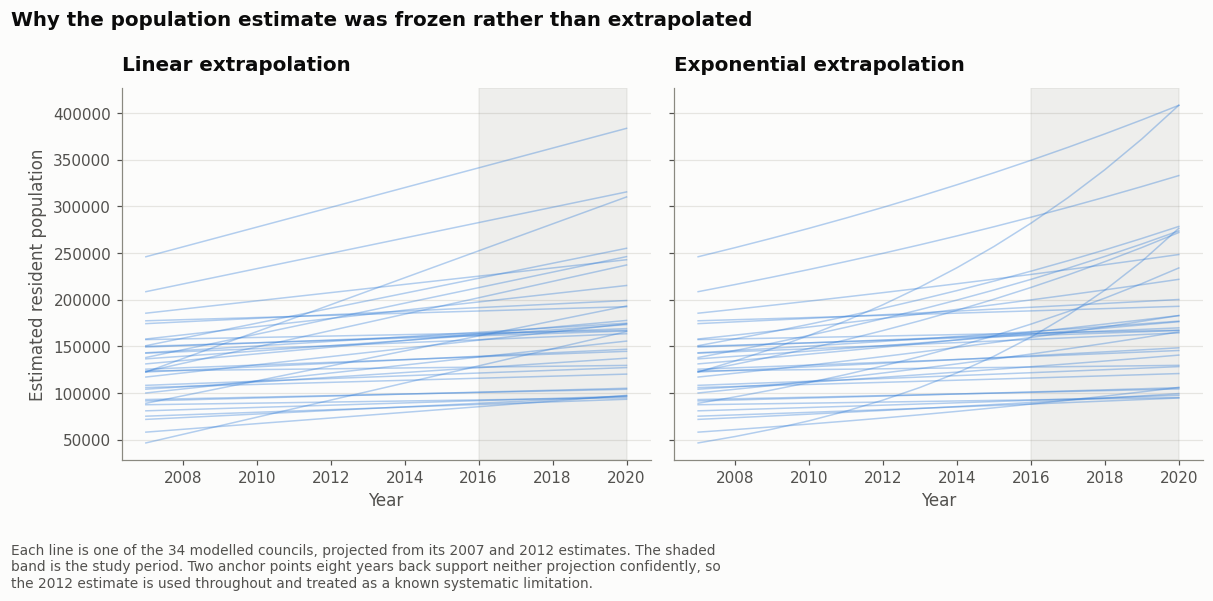

In [9]:
from vichouse.load import load_communities

communities = load_communities()
erp = communities[["LGA", "2007 ERP, total", "2012 ERP, total"]].copy()
erp["LGA"] = erp["LGA"].str.replace(r"\s*\((RC|C|S|B)\)$", "", regex=True).str.strip()
totals = erp.groupby("LGA").sum(numeric_only=True)
totals = totals[(totals > 0).all(axis=1)]

years = np.arange(2007, 2021)
modelled = sorted(df["LGA"].unique())
subset = totals.loc[totals.index.intersection(modelled)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=True)
for ax, kind, title in [
    (axes[0], "linear", "Linear extrapolation"),
    (axes[1], "exponential", "Exponential extrapolation"),
]:
    for lga, row in subset.iterrows():
        p2007, p2012 = row["2007 ERP, total"], row["2012 ERP, total"]
        if kind == "linear":
            slope = (p2012 - p2007) / 5
            curve = p2007 + slope * (years - 2007)
        else:
            rate = (p2012 / p2007) ** (1 / 5)
            curve = p2007 * rate ** (years - 2007)
        ax.plot(years, curve, linewidth=1.0, color=plotting.BLUE, alpha=0.35)
    ax.axvspan(2016, 2020, color=plotting.REFERENCE, alpha=0.12)
    ax.set_title(title)
    ax.set_xlabel("Year")
axes[0].set_ylabel("Estimated resident population")
fig.suptitle(
    "Why the population estimate was frozen rather than extrapolated", x=0.0, ha="left",
    fontsize=13, fontweight="semibold", color=plotting.INK,
)
plotting.caption(
    fig,
    "Each line is one of the 34 modelled councils, projected from its 2007 and 2012 estimates. "
    "The shaded band is the study period. Two anchor points eight years back support neither "
    "projection confidently, so the 2012 estimate is used throughout and treated as a known "
    "systematic limitation.",
)
fig.tight_layout()
plotting.save_fig(fig, "05_population_estimate_error")
plt.show()

## 1.6 Saved outputs

In [10]:
eda = {
    "rows": len(df),
    "lgas": df["LGA"].nunique(),
    "years": df["Year"].nunique(),
    "class_low": int(balance["Low"]),
    "class_medium": int(balance["Medium"]),
    "class_high": int(balance["High"]),
    "majority_class_share": round(majority, 4),
    "price_skew": round(df["Weighted House Price"].skew(), 4),
    "r_price_egm": round(r_egm, 4),
    "r_price_offence": round(r_off, 4),
    "between_lga_variance_offence": round(variance["Offence Rate"], 4),
    "between_lga_variance_egm": round(variance["EGM Rate"], 4),
    "lgas_with_constant_label": int(constant),
}
pd.Series(eda).to_frame("value").to_csv(RESULTS / "eda_summary.csv")
pd.Series(eda).to_frame("value")

,value
rows,170.0000
lgas,34.0000
years,5.0000
class_low,32.0000
class_medium,77.0000
class_high,61.0000
majority_class_share,0.4529
price_skew,1.2104
r_price_egm,-0.4269
r_price_offence,0.0158
